# Agent 3 — Cash-Flow / Balance Forecaster

SARIMAX cash-flow forecaster, converted from `agent3_forecast_model.py`.

**What this notebook fixes vs. the original `train_models.py`:**

1. **No backtest.** The old code fit ARIMA(1,1,1) on the entire 365-day series and pickled it — accuracy never measured.
2. **No baseline.** A forecast is only useful if it beats last-value / seasonal-naive baselines.
3. **Seasonality ignored.** The GL series has a weekly cycle; plain ARIMA(1,1,1) has no seasonal term.
4. **Order assumed, not checked.** `(1,1,1)` hard-coded with no ADF stationarity test.

This notebook holds out the last 30 days as a backtest, compares SARIMAX against two naive baselines (MAE/RMSE/MAPE), runs an ADF test, and ships whichever method actually wins.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
HERE = os.getcwd()
DATA_DIR = os.path.join(HERE, '..', 'data')
MODELS_DIR = os.path.join(HERE, '..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

DATA_FILE = os.path.join(DATA_DIR, 'gl_balances_daily_v2.csv')
if not os.path.exists(DATA_FILE):
    DATA_FILE = os.path.join(DATA_DIR, 'gl_balances_daily.csv')

HORIZON = 30          # days held out for the backtest
ENTITY, CURRENCY = 'Entity A', 'USD'
print('data file:', os.path.basename(DATA_FILE))

data file: gl_balances_daily_v2.csv


In [3]:
def metrics(actual, pred):
    actual, pred = np.asarray(actual, float), np.asarray(pred, float)
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mape = np.mean(np.abs((actual - pred) /
                          np.clip(np.abs(actual), 1e-9, None))) * 100
    return mae, rmse, mape


def report(name, actual, pred):
    mae, rmse, mape = metrics(actual, pred)
    print(f'  {name:22s}  MAE={mae:12,.0f}  RMSE={rmse:12,.0f}  MAPE={mape:6.2f}%')
    return rmse

## Load the balance series

In [4]:
df = pd.read_csv(DATA_FILE)
ts = df[(df.entity == ENTITY) & (df.currency == CURRENCY)].copy()
ts['date'] = pd.to_datetime(ts['date'])
ts = ts.sort_values('date').set_index('date')['balance'].asfreq('D')
print(f'series: {ENTITY}/{CURRENCY}  length={len(ts)} days')
ts.tail()

series: Entity A/USD  length=365 days


date
2025-12-27    1311497.43
2025-12-28    1274593.04
2025-12-29    1283510.27
2025-12-30    1275301.13
2025-12-31    1123581.16
Freq: D, Name: balance, dtype: float64

## ADF stationarity check — justifies the differencing order *d*

In [5]:
adf_p = adfuller(ts.dropna())[1]
print(f'[ADF] p-value on raw series      = {adf_p:.4f} '
      f"({'stationary' if adf_p < 0.05 else 'non-stationary -> needs d>=1'})")
adf_p_diff = adfuller(ts.diff().dropna())[1]
print(f'[ADF] p-value after 1 difference = {adf_p_diff:.4f} '
      f"({'stationary' if adf_p_diff < 0.05 else 'still non-stationary'})")

[ADF] p-value on raw series      = 0.0801 (non-stationary -> needs d>=1)
[ADF] p-value after 1 difference = 0.0000 (stationary)


## Train / backtest split + models

In [6]:
train, test = ts.iloc[:-HORIZON], ts.iloc[-HORIZON:]
print(f'train={len(train)} days   backtest={len(test)} days')

print(f'--- Backtest over the last {HORIZON} days ---')
# Baseline 1: last observed value carried forward.
naive = np.repeat(train.iloc[-1], HORIZON)
report('naive (last value)', test, naive)

# Baseline 2: seasonal naive -- repeat the value from 7 days earlier.
seasonal_naive = [train.iloc[-7 + (i % 7)] for i in range(HORIZON)]
report('seasonal naive (t-7)', test, seasonal_naive)

# SARIMAX with a weekly seasonal component.
order, seasonal_order = (1, 1, 1), (1, 0, 1, 7)
sarimax = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False,
                  enforce_invertibility=False).fit(disp=False)
fc = sarimax.get_forecast(steps=HORIZON).predicted_mean
sarimax_rmse = report(f'SARIMAX{order}x{seasonal_order}', test, fc)

# Plain ARIMA(1,1,1) -- the original model, for direct comparison.
arima = SARIMAX(train, order=(1, 1, 1)).fit(disp=False)
arima_fc = arima.get_forecast(steps=HORIZON).predicted_mean
arima_rmse = report('ARIMA(1,1,1) [original]', test, arima_fc)

train=335 days   backtest=30 days
--- Backtest over the last 30 days ---
  naive (last value)      MAE=     100,421  RMSE=     134,203  MAPE=  8.68%
  seasonal naive (t-7)    MAE=     107,514  RMSE=     133,914  MAPE=  9.19%
  SARIMAX(1, 1, 1)x(1, 0, 1, 7)  MAE=     135,023  RMSE=     173,731  MAPE= 11.79%
  ARIMA(1,1,1) [original]  MAE=     104,905  RMSE=     140,490  MAPE=  9.14%


## Plot — forecasts vs. actual over the backtest window

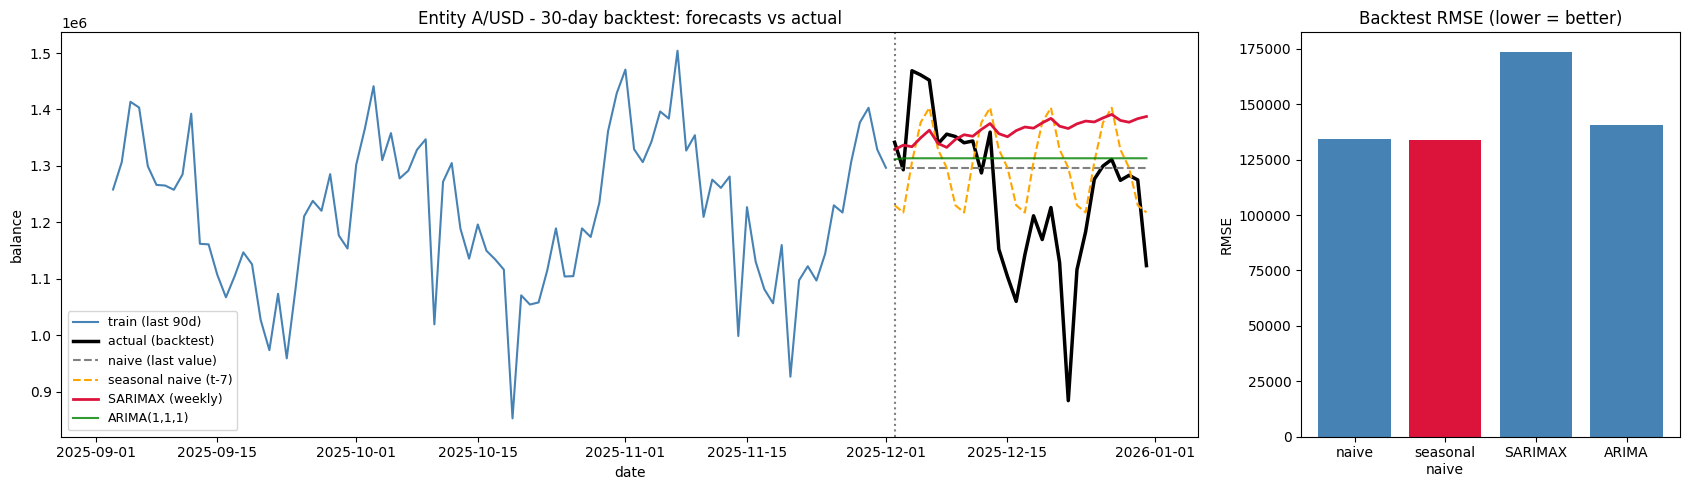

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5),
                               gridspec_kw={'width_ratios': [3, 1]})

# Forecasts vs actual
ax1.plot(train.index[-90:], train.values[-90:],
         color='steelblue', label='train (last 90d)')
ax1.plot(test.index, test.values, color='black', lw=2.5,
         label='actual (backtest)')
ax1.plot(test.index, naive, '--', color='gray',
         label='naive (last value)')
ax1.plot(test.index, seasonal_naive, '--', color='orange',
         label='seasonal naive (t-7)')
ax1.plot(test.index, fc.values, color='crimson', lw=2,
         label='SARIMAX (weekly)')
ax1.plot(test.index, arima_fc.values, color='green', alpha=0.8,
         label='ARIMA(1,1,1)')
ax1.axvline(test.index[0], color='black', ls=':', alpha=0.5)
ax1.set_title(f'{ENTITY}/{CURRENCY} - {HORIZON}-day backtest: forecasts vs actual')
ax1.set_xlabel('date'); ax1.set_ylabel('balance'); ax1.legend(fontsize=9)

# RMSE comparison bar chart
rmse_vals = {
    'naive': metrics(test, naive)[1],
    'seasonal\nnaive': metrics(test, seasonal_naive)[1],
    'SARIMAX': sarimax_rmse,
    'ARIMA': arima_rmse,
}
names = list(rmse_vals)
vals = [rmse_vals[n] for n in names]
bcolors = ['crimson' if v == min(vals) else 'steelblue' for v in vals]
ax2.bar(names, vals, color=bcolors)
ax2.set_title('Backtest RMSE (lower = better)')
ax2.set_ylabel('RMSE')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

## Model selection — ship whatever won the backtest

In [8]:
scores = {
    'seasonal_naive': metrics(test, seasonal_naive)[1],
    'sarimax': sarimax_rmse,
    'arima': arima_rmse,
}
winner = min(scores, key=scores.get)
print(f">> Backtest winner: '{winner}' (RMSE={scores[winner]:,.0f}).")
if winner == 'seasonal_naive':
    print('   The seasonal-naive baseline wins -- a heavier model is NOT')
    print('   justified for this series. Shipping the baseline forecaster.')
else:
    print(f"   '{winner}' beats the naive baseline -- shipping it.")

>> Backtest winner: 'seasonal_naive' (RMSE=133,914).
   The seasonal-naive baseline wins -- a heavier model is NOT
   justified for this series. Shipping the baseline forecaster.


## Serialise the winning method

The pickle is a **dict**: `method` + `model`/`last_week` + backtest RMSE.

In [9]:
bundle = {
    'entity': ENTITY, 'currency': CURRENCY,
    'method': winner,
    'backtest_rmse': float(scores[winner]),
    'backtest_horizon': HORIZON,
    'backtest_scores': {k: float(v) for k, v in scores.items()},
}
if winner == 'seasonal_naive':
    # The "model" is just the last weekly cycle of observed values.
    bundle['last_week'] = ts.iloc[-7:].tolist()
    bundle['model'] = None
else:
    ord_, sord_ = ((order, seasonal_order) if winner == 'sarimax'
                   else ((1, 1, 1), (0, 0, 0, 0)))
    bundle['model'] = SARIMAX(ts, order=ord_, seasonal_order=sord_,
                              enforce_stationarity=False,
                              enforce_invertibility=False).fit(disp=False)
    bundle['order'], bundle['seasonal_order'] = ord_, sord_

out = os.path.join(MODELS_DIR, 'forecast_model.pkl')
with open(out, 'wb') as f:
    pickle.dump(bundle, f)
print(f'Saved {out}')
print(f"  (pickle is a dict: method='{winner}' + model/last_week + backtest RMSE)")

Saved C:\CATAS\CATAS\ml\..\models\forecast_model.pkl
  (pickle is a dict: method='seasonal_naive' + model/last_week + backtest RMSE)
